In [9]:
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import cv2
import numpy as np
import seaborn as sns
from PIL import Image
from sqlalchemy import create_engine

# 폰트 설정
font_path = 'C:\Windows\Fonts\gulim.ttc' 
fontprop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = fontprop.get_name()

In [2]:
# DB 연결 정보 설정
DB_USER = 'farmorai_admin'
DB_PASSWORD = 'farmorai12345'
DB_HOST = '192.168.0.13'  # 또는 특정 IP
DB_PORT = '3306'         # 포트 번호
DB_NAME = 'farmdb'

# SQLAlchemy 엔진 생성
engine = create_engine(f'mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

# SQL 쿼리 작성 및 DataFrame으로 변환
sql = "SELECT * FROM apple_label_dataset"
df = pd.read_sql(sql, engine)

In [19]:
df.columns

Index(['index', 'cate1', 'cate2', 'cate3', 'width', 'height', 'weight', 'repo',
       'img_height', 'img_width', 'date', 'resolution', 'bit', 'truncated',
       'angle_direction', 'verticality_angle', 'horizontality_angle', 'bndbox',
       'file_name', 'camera_model', 'camera_software'],
      dtype='object')

C:\Users\KOSMO\AppData\Local\Temp\ipykernel_13984\895304103.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cate3', data=df, palette='dark')


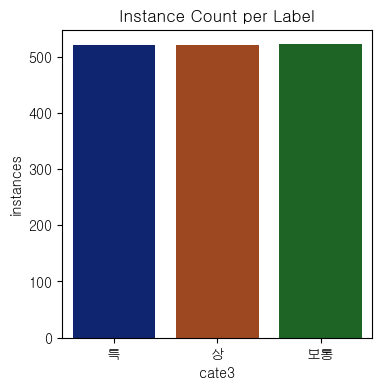

In [16]:
# 바 그래프 (라벨별 인스턴스 개수 시각화)
plt.figure(figsize=(4, 4))
sns.countplot(x='cate3', data=df, palette='dark')
plt.xticks(rotation=0)
plt.ylabel('instances')
plt.title('Instance Count per Label')
plt.show()

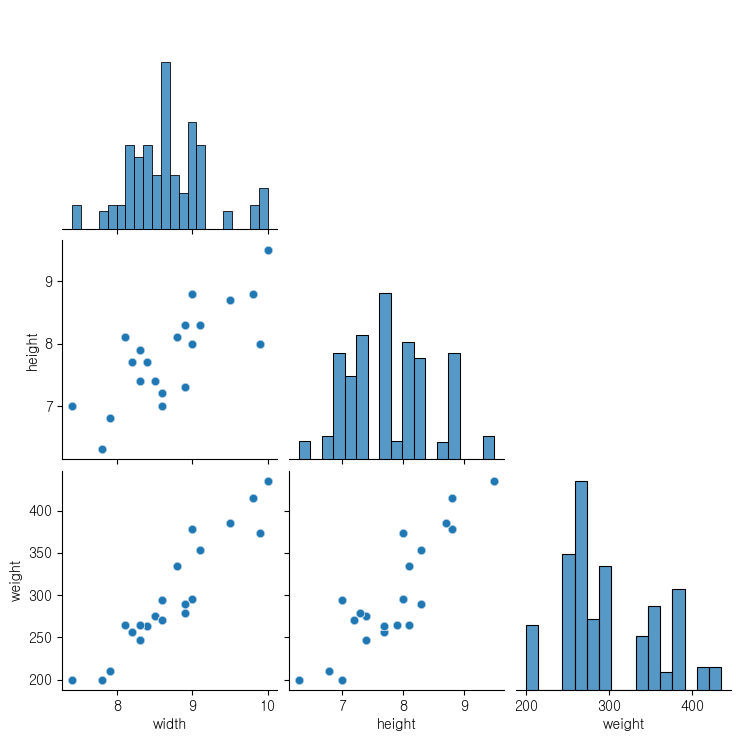

In [32]:
# pairplot: width, height, weight 간의 관계를 분석하고, cate3 카테고리로 색상 구분
sns.pairplot(df[['width', 'height', 'weight']], diag_kind='hist', corner=True, plot_kws={'alpha': 0.3})

plt.show()

width:  9.03903903903904 height:  8.78978978978979
width:  8.59099099099099 height:  7.193893893893894
width:  8.2998998998999 height:  7.701401401401402


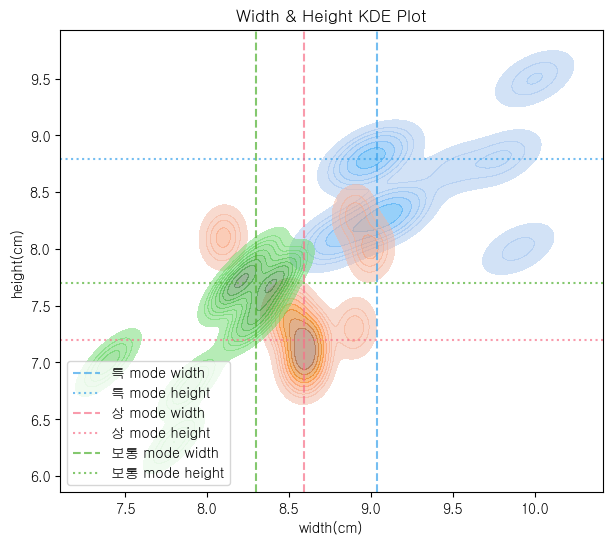

In [55]:
from scipy.stats import gaussian_kde

plt.figure(figsize=(7, 6))

# KDE 플롯 (hue 사용)
ax = sns.kdeplot(
   x=df['width'], 
   y=df['height'], 
   hue=df['cate3'], 
   fill=True, 
   alpha=0.5
)

# hue별 최빈값 찾기
categories = df['cate3'].unique()
colors = sns.color_palette("husl", len(df['cate3'].unique()))  # 고유 카테고리별 색상 지정

for idx, category in enumerate(categories):
   subset = df[df['cate3'] == category]

   # width 최빈값 찾기
   kde_width = gaussian_kde(subset['width'])
   width_vals = np.linspace(subset['width'].min(), subset['width'].max(), 1000)
   mode_width = width_vals[np.argmax(kde_width(width_vals))]

   # height 최빈값 찾기
   kde_height = gaussian_kde(subset['height'])
   height_vals = np.linspace(subset['height'].min(), subset['height'].max(), 1000)
   mode_height = height_vals[np.argmax(kde_height(height_vals))]

   print('width: ', mode_width, 'height: ', mode_height)
   
   # 수직 및 수평선 추가
   plt.axvline(mode_width, linestyle='--', color=colors[idx-1], alpha=0.7, label=f'{category} mode width')
   plt.axhline(mode_height, linestyle=':', color=colors[idx-1], alpha=0.7, label=f'{category} mode height')

plt.xlabel('width(cm)')
plt.ylabel('height(cm)')
plt.title('Width & Height KDE Plot')

plt.legend()
plt.show()

In [65]:
import math
df['volume'] =  (4/3) * math.pi * ((df['width']/2)**2) * (df['height']/2)
df.columns

Index(['index', 'cate1', 'cate2', 'cate3', 'width', 'height', 'weight', 'repo',
       'img_height', 'img_width', 'date', 'resolution', 'bit', 'truncated',
       'angle_direction', 'verticality_angle', 'horizontality_angle', 'bndbox',
       'file_name', 'camera_model', 'camera_software', 'volume'],
      dtype='object')

volume:  366.32500779720596 weight:  377.978978978979
volume:  276.9361200024847 weight:  272.32732732732734
volume:  273.73989382620147 weight:  259.72972972972974


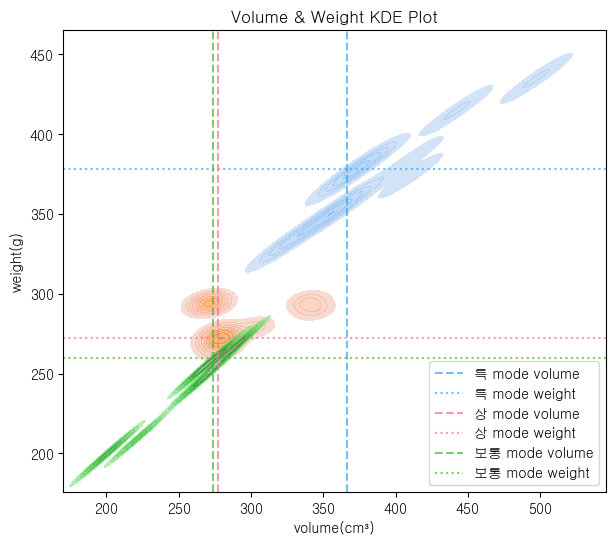

In [68]:
from scipy.stats import gaussian_kde

plt.figure(figsize=(7, 6))

# KDE 플롯 (hue 사용)
ax = sns.kdeplot(
   x=df['volume'], 
   y=df['weight'], 
   hue=df['cate3'], 
   fill=True, 
   alpha=0.5
)

# hue별 최빈값 찾기
categories = df['cate3'].unique()
colors = sns.color_palette("husl", len(df['cate3'].unique()))  # 고유 카테고리별 색상 지정

for idx, category in enumerate(categories):
   subset = df[df['cate3'] == category]

   # width 최빈값 찾기
   kde_width = gaussian_kde(subset['volume'])
   width_vals = np.linspace(subset['volume'].min(), subset['volume'].max(), 1000)
   mode_width = width_vals[np.argmax(kde_width(width_vals))]

   # height 최빈값 찾기
   kde_height = gaussian_kde(subset['weight'])
   height_vals = np.linspace(subset['weight'].min(), subset['weight'].max(), 1000)
   mode_height = height_vals[np.argmax(kde_height(height_vals))]

   print('volume: ', mode_width, 'weight: ', mode_height)
   
   # 수직 및 수평선 추가
   plt.axvline(mode_width, linestyle='--', color=colors[idx-1], alpha=0.7, label=f'{category} mode volume')
   plt.axhline(mode_height, linestyle=':', color=colors[idx-1], alpha=0.7, label=f'{category} mode weight')

plt.xlabel('volume(cm³)')
plt.ylabel('weight(g)')
plt.title('Volume & Weight KDE Plot')

plt.legend(loc='lower right')
plt.show()